In [6]:
#important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [26]:
df=pd.read_csv('/content/Indian Liver Patient Dataset (ILPD).csv')
df.sample(3)

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
12,64,Male,0.9,0.3,310,61,58,7.0,3.4,0.90,2
186,60,Male,3.2,1.8,750,79,145,7.8,3.2,0.69,1
20,51,Male,2.2,1.0,610,17,28,7.3,2.6,0.55,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    int64  
 1   gender            583 non-null    object 
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    int64  
 5   albumin           583 non-null    int64  
 6   ag_ratio          583 non-null    int64  
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


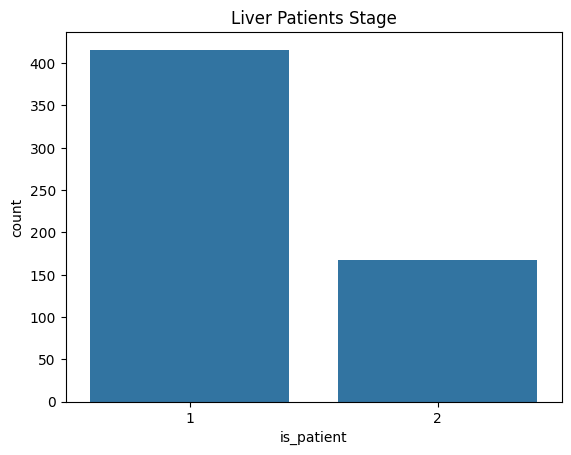

In [8]:
sns.countplot(data=df,x='is_patient')
plt.title('Liver Patients Stage')
plt.show()

In [27]:
df['alkphos']=df['alkphos'].fillna(df['alkphos'].median())
df['is_patient']=df['is_patient'].map({1:1,2:0})

In [28]:
df.sample()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
440,49,Female,0.8,0.2,198,23,20,7.0,4.3,1.5,1


In [29]:
# This checks if the column is still text (object) before trying to map it
if df['gender'].dtype == 'O':
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [30]:
print(df.isnull().sum())

age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             0
is_patient          0
dtype: int64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    int64  
 1   gender            583 non-null    int64  
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    int64  
 5   albumin           583 non-null    int64  
 6   ag_ratio          583 non-null    int64  
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           583 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 50.2 KB


In [32]:
df.sample(5)

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
215,66,1,0.6,0.2,100,17,148,5.0,3.3,1.9,0
66,54,1,2.2,1.2,195,55,95,6.0,3.7,1.6,1
573,32,1,3.7,1.6,612,50,88,6.2,1.9,0.4,1
404,22,1,0.8,0.2,198,20,26,6.8,3.9,1.3,1
536,46,1,15.8,7.2,227,67,220,6.9,2.6,0.6,1


In [33]:
X = df.drop('is_patient', axis=1)
y = df['is_patient']

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=.8,random_state=42)

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred = model.predict(X_test_scaled)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7350427350427351


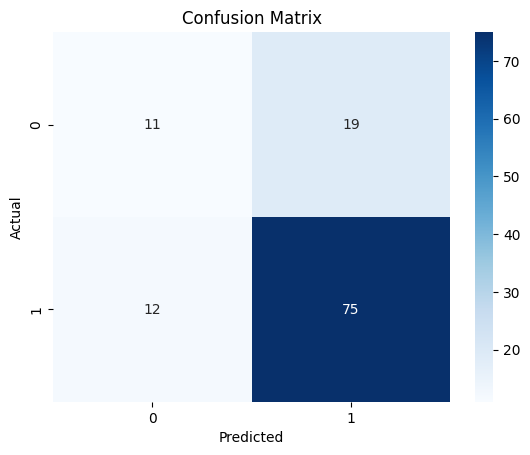

In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:


def liver_disease_predictor():
    print("=== Liver Disease Risk Predictor ===")
    print("Please enter the patient's blood test results:\n")

    try:

        age = float(input("Age: "))


        gender_str = input("Gender (Male/Female): ").strip().lower()
        gender = 1 if gender_str == 'male' else 0


        tot_bilirubin = float(input("Total Bilirubin: "))
        direct_bilirubin = float(input("Direct Bilirubin: "))
        tot_proteins = float(input("Total Proteins: "))
        albumin = float(input("Albumin: "))
        ag_ratio = float(input("A/G Ratio: "))
        sgpt = float(input("SGPT: "))
        sgot = float(input("SGOT: "))
        alkphos = float(input("Alkaline Phosphatase: "))


        user_input_df = pd.DataFrame({
            'age': [age],
            'gender': [gender],
            'tot_bilirubin': [tot_bilirubin],
            'direct_bilirubin': [direct_bilirubin],
            'tot_proteins': [tot_proteins],
            'albumin': [albumin],
            'ag_ratio': [ag_ratio],
            'sgpt': [sgpt],
            'sgot': [sgot],
            'alkphos': [alkphos]
        })


        input_scaled = scaler.transform(user_input_df)


        prediction = model.predict(input_scaled)

        print("\n--- PREDICTION RESULT ---")
        if prediction[0] == 1:
            print("The model predicts: Patient is at risk for liver disease.")
        else:
            print("The model predicts: Patient is NOT at risk for liver disease.")

    except ValueError:
        print("\nError: Please make sure you are entering numerical values for the test results.")


liver_disease_predictor()

=== Liver Disease Risk Predictor ===
Please enter the patient's blood test results:

Age: 46
Gender (Male/Female): Female
Total Bilirubin: 10.2
Direct Bilirubin: 4.2
Total Proteins: 232
Albumin: 58
A/G Ratio: 140
SGPT: 7
SGOT: 2.7
Alkaline Phosphatase: .6

--- PREDICTION RESULT ---
The model predicts: Patient is at risk for liver disease.


In [43]:
df.sample()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
553,46,1,10.2,4.2,232,58,140,7.0,2.7,0.6,1
